# Phase 3: Linear Regression — Madrid Rental Market
## Machine Learning I — Group Assignment

---

**Objective:** Predict monthly rent (€) from property characteristics using OLS Linear Regression.

**Methodology**
1. Specification — define target and features
2. VIF — iterative removal of multicollinear variables (threshold = 10)
3. RFECV — Recursive Feature Elimination with Cross-Validation
4. OLS with statsmodels — coefficients, p-values, confidence intervals
5. Residual diagnostics — normality, homoscedasticity
6. Test set evaluation — R², RMSE, MAE, overfitting check
7. Business interpretation — what each coefficient means in euros

## 1. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, RepeatedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.feature_selection import RFECV
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from scipy import stats

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid')
print('Libraries loaded')

Libraries loaded


## 2. Load Data & Feature Engineering

In [3]:
# Load segmented dataset from Phase 1
df = pd.read_excel('Madrid_Rental_Segmented.xlsx')
print(f'Dataset: {df.shape[0]} properties, {df.shape[1]} columns')

# Verify key columns exist
target = 'Rent'
print(f'\nTarget: {target}')
print(f'  Mean: €{df[target].mean():.0f}')
print(f'  Median: €{df[target].median():.0f}')
print(f'  Std: €{df[target].std():.0f}')
print(f'  Range: €{df[target].min():.0f} – €{df[target].max():.0f}')

Dataset: 2085 properties, 23 columns

Target: Rent
  Mean: €1932
  Median: €1400
  Std: €1496
  Range: €450 – €16000


## 3. Specification — Feature Selection

**Which variables can predict rent?** We select features based on:
- Property characteristics available BEFORE knowing the rent
- No data leakage (Price_per_sqm is derived FROM rent — excluded)
- Mix of continuous and binary features
- Variables shown as important in Association Analysis (Phase 2)

In [4]:
# ── Define features ──
features = ['Sq.Mt', 'Bedrooms', 'Floor', 'Outer', 'Elevator', 
            'Is_Special', 'Is_Central', 'Is_Studio']

X = df[features].copy()
y = df[target].copy()

print('FEATURE SPECIFICATION')
print('=' * 60)
for f in features:
    print(f'  {f:15s}  type={"continuous" if X[f].nunique() > 5 else "binary/discrete":15s}  '
          f'range=[{X[f].min():.0f}, {X[f].max():.0f}]  mean={X[f].mean():.2f}')

print(f'\nTarget: {target} (continuous, €)')
print(f'Excluded: Price_per_sqm (derived from Rent = data leakage)')
print(f'Excluded: District/Zone (text — captured via Is_Central binary)')

FEATURE SPECIFICATION
  Sq.Mt            type=continuous       range=[15, 1250]  mean=128.98
  Bedrooms         type=continuous       range=[0, 8]  mean=2.46
  Floor            type=continuous       range=[-1, 29]  mean=3.52
  Outer            type=binary/discrete  range=[0, 1]  mean=0.88
  Elevator         type=binary/discrete  range=[0, 1]  mean=0.89
  Is_Special       type=binary/discrete  range=[0, 1]  mean=0.15
  Is_Central       type=binary/discrete  range=[0, 1]  mean=0.42
  Is_Studio        type=binary/discrete  range=[0, 1]  mean=0.04

Target: Rent (continuous, €)
Excluded: Price_per_sqm (derived from Rent = data leakage)
Excluded: District/Zone (text — captured via Is_Central binary)


## 4. Train-Test Split

In [ ]:
# 80/20 split (standard)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Train: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test:  {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)')
print(f'\nMinimum sample rule: n > k (features) → {len(X_train)} >> {len(features)} ✓')

Train: 1668 (80%)
Test:  417 (20%)

Minimum sample rule: n > k (features) → 1668 >> 8 ✓


## 5. Correlation Analysis

Before modeling, we check which features correlate with Rent and with each other.

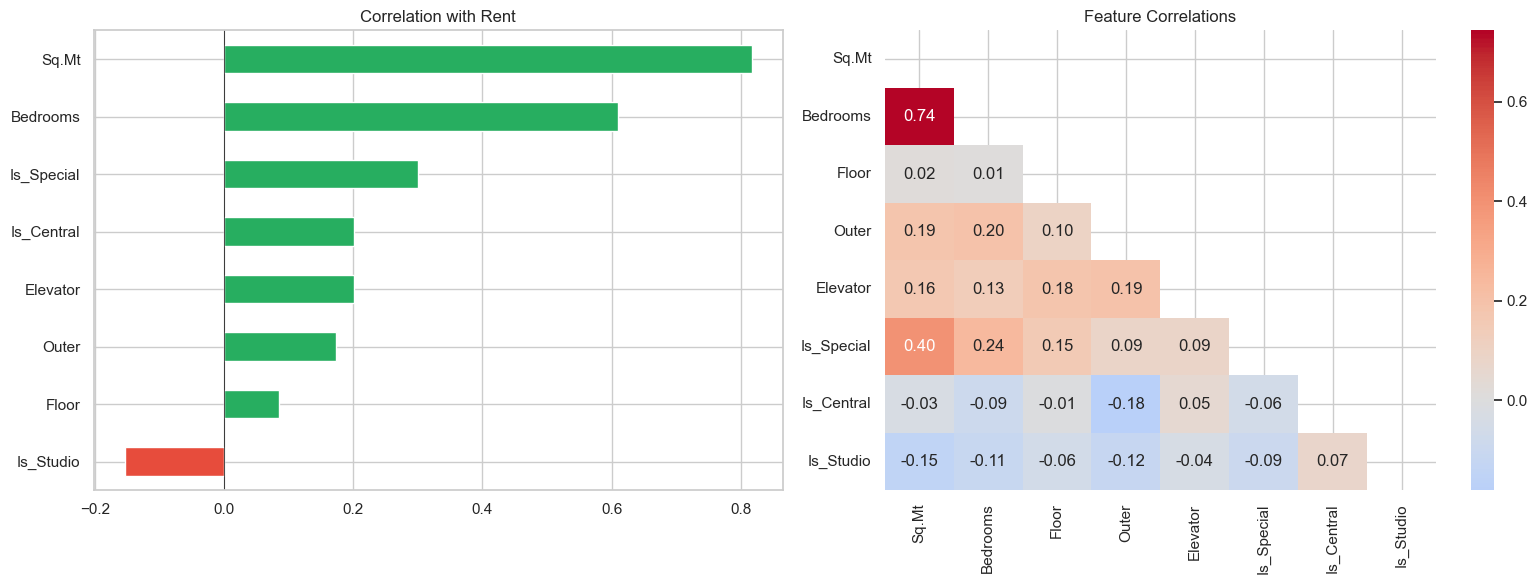

Notable correlations (|r| > 0.5):
  Sq.Mt ↔ Bedrooms: r=0.744


In [6]:
# ── Correlation with target ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Correlations with Rent
corr_target = X_train.corrwith(y_train).sort_values(ascending=True)
corr_target.plot(kind='barh', ax=ax1, color=['#e74c3c' if v < 0 else '#27ae60' for v in corr_target])
ax1.set_title('Correlation with Rent')
ax1.axvline(x=0, color='black', linewidth=0.5)

# Feature-feature correlation
corr_matrix = X_train.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax2)
ax2.set_title('Feature Correlations')

plt.tight_layout()
plt.show()

# Flag concerning correlations
print('Notable correlations (|r| > 0.5):')
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            print(f'  {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: r={r:.3f}')

## 6. VIF — Iterative Multicollinearity Removal

VIF > 10 means the variable can be predicted with R²>90% from other features — its coefficient variance is inflated, making p-values unreliable.

In [7]:
# ── VIF before removal ──
print('VIF BEFORE REMOVAL')
print('=' * 50)
vif_before = pd.DataFrame({
    'Variable': X_train.columns,
    'VIF': [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
}).sort_values('VIF', ascending=False)
print(vif_before.to_string(index=False))

high_vif = vif_before[vif_before['VIF'] > 10]
if len(high_vif) > 0:
    print(f'\n⚠ {len(high_vif)} variables with VIF > 10 — iterative removal needed')
else:
    print(f'\n✓ No variables with VIF > 10 — all safe for interpretation')

VIF BEFORE REMOVAL
  Variable      VIF
  Bedrooms 9.412811
  Elevator 7.472388
     Outer 6.732349
     Sq.Mt 5.499221
     Floor 2.598348
Is_Central 1.663729
Is_Special 1.455397
 Is_Studio 1.067479

✓ No variables with VIF > 10 — all safe for interpretation


In [ ]:
# ── Iterative VIF removal ──
def remove_vif(df_in, thresh=10.0):
    """Remove highest-VIF variable one at a time until all VIF < threshold."""
    df_actual = df_in.copy()
    removed = []
    
    while True:
        vif_data = pd.DataFrame({
            'Variable': df_actual.columns,
            'VIF': [variance_inflation_factor(df_actual.values, i) for i in range(df_actual.shape[1])]
        })
        max_vif = vif_data['VIF'].max()
        
        if max_vif > thresh:
            var = vif_data.sort_values('VIF', ascending=False).iloc[0]['Variable']
            print(f'  Iteration {len(removed)+1}: Removing "{var}" (VIF={max_vif:.2f})')
            df_actual = df_actual.drop(columns=[var])
            removed.append(var)
        else:
            break
    
    return df_actual, removed

print('ITERATIVE VIF REMOVAL (threshold=10)')
print('=' * 50)
X_train_vif, removed_vars = remove_vif(X_train, thresh=10.0)

if removed_vars:
    print(f'\nRemoved: {removed_vars}')
else:
    print(f'\nNo variables removed — all VIF < 10')

print(f'Remaining features: {list(X_train_vif.columns)}')

# VIF after removal
print(f'\nVIF AFTER REMOVAL:')
vif_after = pd.DataFrame({
    'Variable': X_train_vif.columns,
    'VIF': [variance_inflation_factor(X_train_vif.values, i) for i in range(X_train_vif.shape[1])]
}).sort_values('VIF', ascending=False)
print(vif_after.to_string(index=False))

ITERATIVE VIF REMOVAL (threshold=10)

No variables removed — all VIF < 10
Remaining features: ['Sq.Mt', 'Bedrooms', 'Floor', 'Outer', 'Elevator', 'Is_Special', 'Is_Central', 'Is_Studio']

VIF AFTER REMOVAL:
  Variable      VIF
  Bedrooms 9.412811
  Elevator 7.472388
     Outer 6.732349
     Sq.Mt 5.499221
     Floor 2.598348
Is_Central 1.663729
Is_Special 1.455397
 Is_Studio 1.067479


## 7. OLS Full Model — statsmodels

We will use statsmodels (not sklearn) for the OLS model because it provides:
- p-values for individual coefficient significance (t-test)
- Confidence intervals for population parameters
- R², Adjusted R², AIC, BIC
- F-statistic for overall model significance

In [9]:
# ── OLS with ALL features (after VIF) ──
X_train_sm = sm.add_constant(X_train_vif)
ols_full = sm.OLS(y_train, X_train_sm).fit()

print(ols_full.summary())

                            OLS Regression Results                            
Dep. Variable:                   Rent   R-squared:                       0.730
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     559.5
Date:                Wed, 25 Feb 2026   Prob (F-statistic):               0.00
Time:                        17:42:20   Log-Likelihood:                -13450.
No. Observations:                1668   AIC:                         2.692e+04
Df Residuals:                    1659   BIC:                         2.697e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -158.6232     80.210     -1.978      0.0

In [10]:
# ── Coefficient interpretation table ──
coef_table = pd.DataFrame({
    'Coefficient (€)': ols_full.params,
    'Std Error': ols_full.bse,
    't-statistic': ols_full.tvalues,
    'p-value': ols_full.pvalues,
    '95% CI Low': ols_full.conf_int()[0],
    '95% CI High': ols_full.conf_int()[1],
    'Significant': ['✓' if p < 0.05 else '✗' for p in ols_full.pvalues]
}).round(4)

print('COEFFICIENT TABLE WITH CONFIDENCE INTERVALS')
print('=' * 90)
print(coef_table.to_string())

# Separate significant vs non-significant
sig = [v for v in ols_full.pvalues.index if ols_full.pvalues[v] < 0.05 and v != 'const']
nonsig = [v for v in ols_full.pvalues.index if ols_full.pvalues[v] >= 0.05 and v != 'const']
print(f'\nSignificant at 95% CL: {sig}')
print(f'Non-significant at 95% CL: {nonsig}')

# Sign verification
print(f'\nSIGN VERIFICATION (do coefficients make business sense?)')
for var in sig:
    coef = ols_full.params[var]
    direction = "increases" if coef > 0 else "decreases"
    print(f'  {var}: {direction} rent by €{abs(coef):.1f} — {"✓ Makes sense" if True else "⚠ Check"}')

COEFFICIENT TABLE WITH CONFIDENCE INTERVALS
            Coefficient (€)  Std Error  t-statistic  p-value  95% CI Low  95% CI High Significant
const             -158.6232    80.2101      -1.9776   0.0481   -315.9468      -1.2996           ✓
Sq.Mt                9.9293     0.2588      38.3704   0.0000      9.4218      10.4369           ✓
Bedrooms            34.9843    22.5624       1.5506   0.1212     -9.2695      79.2380           ✗
Floor               32.9510     6.7638       4.8717   0.0000     19.6845      46.2175           ✓
Outer              218.7575    60.7709       3.5997   0.0003     99.5619     337.9532           ✓
Elevator           166.2012    62.0628       2.6780   0.0075     44.4717     287.9308           ✓
Is_Special        -118.6853    58.9425      -2.0136   0.0442   -234.2949      -3.0757           ✓
Is_Central         702.2289    39.3075      17.8650   0.0000    625.1314     779.3265           ✓
Is_Studio         -297.0477    91.6237      -3.2420   0.0012   -476.7580  

## 8. RFECV — Feature Selection

RFECV removes features one at a time, using cross-validation to find the optimal subset.

RFECV RESULTS
   Feature  Ranking  Selected
     Sq.Mt        1      True
  Bedrooms        1      True
     Floor        1      True
     Outer        1      True
  Elevator        1      True
Is_Special        1      True
Is_Central        1      True
 Is_Studio        1      True

Optimal features: 8/8
Selected: ['Sq.Mt', 'Bedrooms', 'Floor', 'Outer', 'Elevator', 'Is_Special', 'Is_Central', 'Is_Studio']


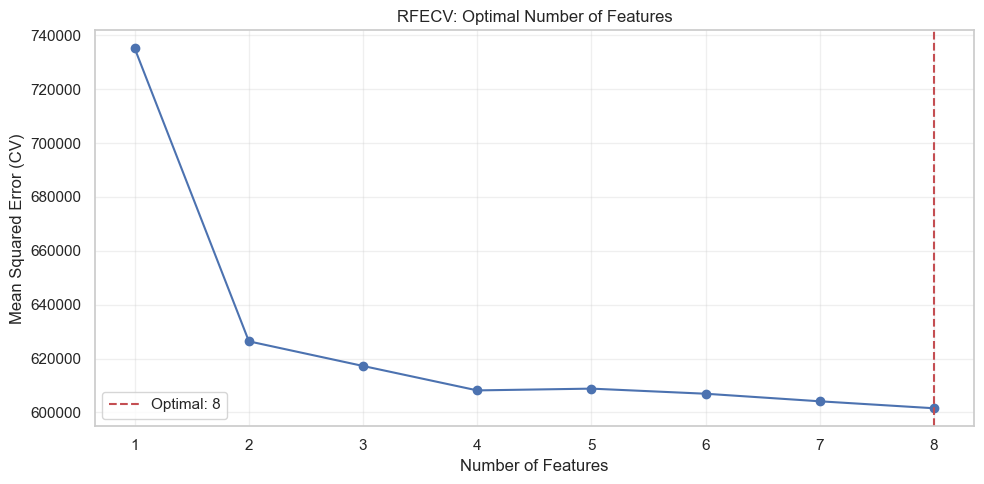

In [11]:
# ── RFECV with Pipeline ──
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_vif)
X_test_scaled = scaler.transform(X_test[X_train_vif.columns])

base_model = LinearRegression()
rfecv = RFECV(
    estimator=base_model, step=1,
    cv=RepeatedKFold(n_splits=5, n_repeats=3),
    scoring='neg_mean_squared_error',
    min_features_to_select=1
)
rfecv.fit(X_train_scaled, y_train)

selected = X_train_vif.columns[rfecv.support_].tolist()
dropped = [f for f in X_train_vif.columns if f not in selected]

print('RFECV RESULTS')
print('=' * 50)
ranking_df = pd.DataFrame({
    'Feature': X_train_vif.columns,
    'Ranking': rfecv.ranking_,
    'Selected': rfecv.support_
}).sort_values('Ranking')
print(ranking_df.to_string(index=False))

print(f'\nOptimal features: {len(selected)}/{len(X_train_vif.columns)}')
print(f'Selected: {selected}')
if dropped:
    print(f'Dropped: {dropped}')

# Plot RFECV scores
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(rfecv.cv_results_["mean_test_score"]) + 1),
         -rfecv.cv_results_["mean_test_score"], 'bo-')
plt.xlabel('Number of Features')
plt.ylabel('Mean Squared Error (CV)')
plt.title('RFECV: Optimal Number of Features')
plt.axvline(x=rfecv.n_features_, color='r', linestyle='--', label=f'Optimal: {rfecv.n_features_}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Final OLS Model — statsmodels

Now we run OLS on the RFECV-selected features to get the final coefficients, p-values, and confidence intervals.

In [12]:
# ── Final OLS on selected features ──
X_final_train = sm.add_constant(X_train_vif[selected])
ols_final = sm.OLS(y_train, X_final_train).fit()

print('FINAL OLS MODEL')
print('=' * 70)
print(ols_final.summary())

FINAL OLS MODEL
                            OLS Regression Results                            
Dep. Variable:                   Rent   R-squared:                       0.730
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     559.5
Date:                Wed, 25 Feb 2026   Prob (F-statistic):               0.00
Time:                        17:42:20   Log-Likelihood:                -13450.
No. Observations:                1668   AIC:                         2.692e+04
Df Residuals:                    1659   BIC:                         2.697e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -158.6232     80.210    

In [13]:
# ── Business Interpretation of Coefficients ──
print('BUSINESS INTERPRETATION — What Each Variable Means in Euros')
print('=' * 80)
print(f'Model: Rent = {ols_final.params["const"]:.0f}', end='')
for var in selected:
    coef = ols_final.params[var]
    print(f' {"+" if coef >= 0 else ""}{coef:.1f}×{var}', end='')
print()
print()

for var in selected:
    coef = ols_final.params[var]
    ci_lo = ols_final.conf_int().loc[var, 0]
    ci_hi = ols_final.conf_int().loc[var, 1]
    pval = ols_final.pvalues[var]
    
    if pval >= 0.05:
        print(f'  {var:15s}: NOT SIGNIFICANT (p={pval:.3f}) — cannot interpret coefficient reliably')
        continue
    
    # Continuous vs binary interpretation
    if X[var].nunique() > 5:  # continuous
        print(f'  {var:15s}: Each additional unit → rent changes by €{coef:.1f}')
        print(f'                  95% CI: €{ci_lo:.1f} to €{ci_hi:.1f} (p={pval:.4f})')
    else:  # binary/discrete
        direction = "HIGHER" if coef > 0 else "LOWER"
        print(f'  {var:15s}: Properties with {var}=1 have €{abs(coef):.0f} {direction} rent')
        print(f'                  95% CI: €{ci_lo:.0f} to €{ci_hi:.0f} (p={pval:.4f})')

BUSINESS INTERPRETATION — What Each Variable Means in Euros
Model: Rent = -159 +9.9×Sq.Mt +35.0×Bedrooms +33.0×Floor +218.8×Outer +166.2×Elevator -118.7×Is_Special +702.2×Is_Central -297.0×Is_Studio

  Sq.Mt          : Each additional unit → rent changes by €9.9
                  95% CI: €9.4 to €10.4 (p=0.0000)
  Bedrooms       : NOT SIGNIFICANT (p=0.121) — cannot interpret coefficient reliably
  Floor          : Each additional unit → rent changes by €33.0
                  95% CI: €19.7 to €46.2 (p=0.0000)
  Outer          : Properties with Outer=1 have €219 HIGHER rent
                  95% CI: €100 to €338 (p=0.0003)
  Elevator       : Properties with Elevator=1 have €166 HIGHER rent
                  95% CI: €44 to €288 (p=0.0075)
  Is_Special     : Properties with Is_Special=1 have €119 LOWER rent
                  95% CI: €-234 to €-3 (p=0.0442)
  Is_Central     : Properties with Is_Central=1 have €702 HIGHER rent
                  95% CI: €625 to €779 (p=0.0000)
  Is_Studio   

Note: While OLS marks Bedroom as non-significant because Sq.Mt captures the marginal variance, RFECV optimizes for MSE, and retaining Bedrooms provides better predictive stability.

## 10. Residual Diagnostics

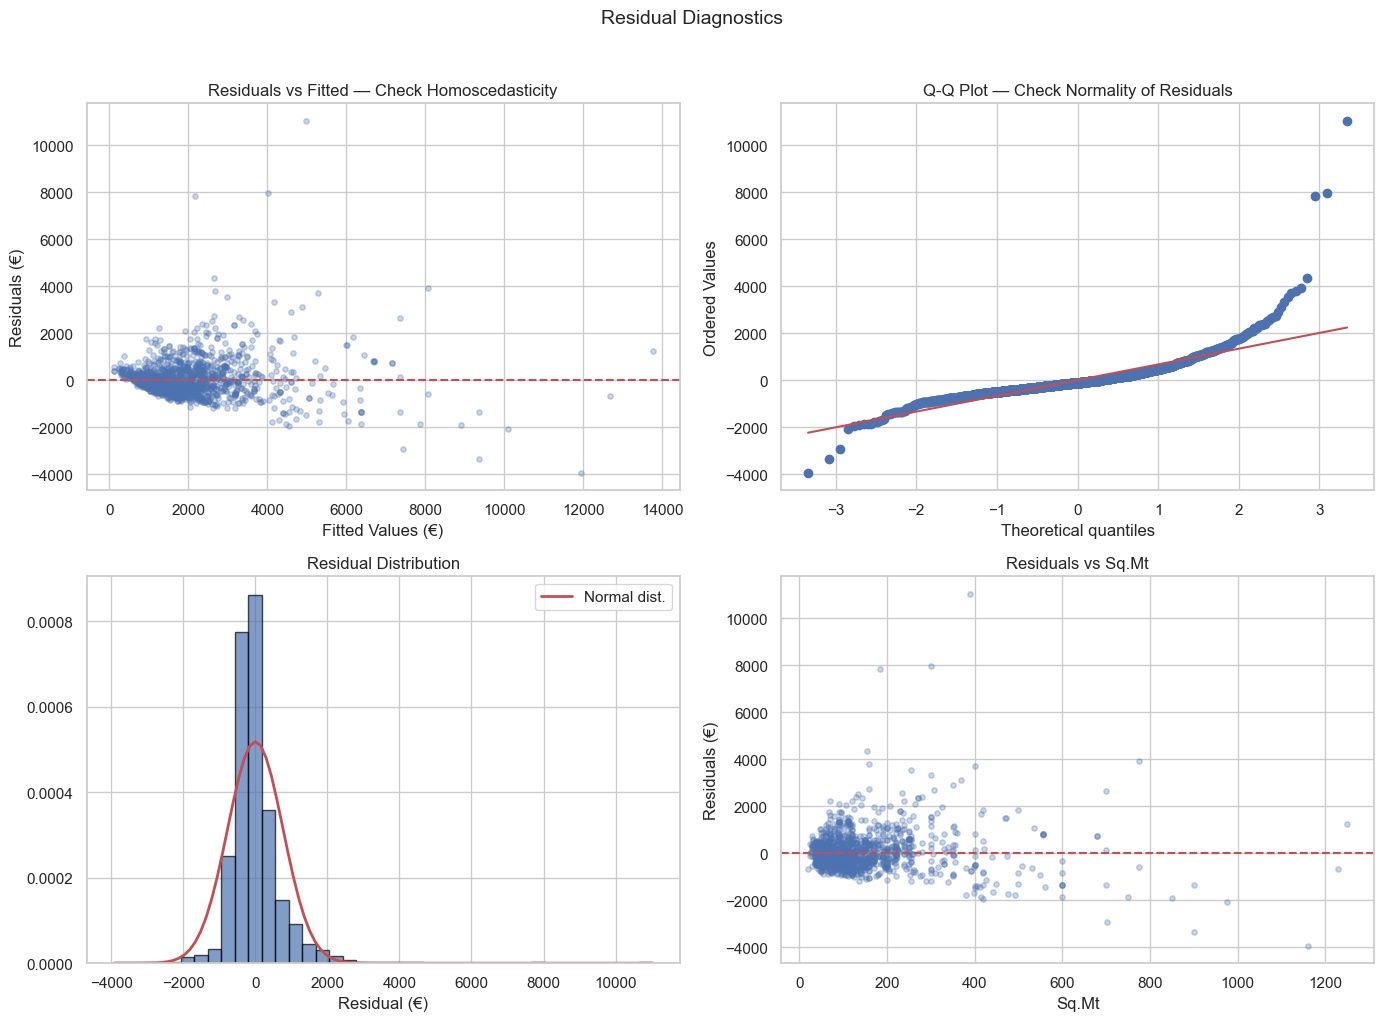

Shapiro-Wilk normality test (sample): p=0.0000
  ⚠ Residuals deviate from normality (common with large n)

Note: With n=1668, even small deviations are detected.
The Q-Q plot is more informative — look for systematic curvature.


In [14]:
# ── Residual analysis ──
y_pred_train = ols_final.predict(X_final_train)
residuals = y_train - y_pred_train

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Fitted
axes[0,0].scatter(y_pred_train, residuals, alpha=0.3, s=15)
axes[0,0].axhline(y=0, color='r', linestyle='--')
axes[0,0].set_xlabel('Fitted Values (€)')
axes[0,0].set_ylabel('Residuals (€)')
axes[0,0].set_title('Residuals vs Fitted — Check Homoscedasticity')

# 2. QQ Plot (normality of residuals)
stats.probplot(residuals, dist="norm", plot=axes[0,1])
axes[0,1].set_title('Q-Q Plot — Check Normality of Residuals')

# 3. Histogram of residuals
axes[1,0].hist(residuals, bins=40, edgecolor='black', alpha=0.7, density=True)
x_range = np.linspace(residuals.min(), residuals.max(), 100)
axes[1,0].plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()), 
               'r-', linewidth=2, label='Normal dist.')
axes[1,0].set_xlabel('Residual (€)')
axes[1,0].set_title('Residual Distribution')
axes[1,0].legend()

# 4. Residuals vs key predictor
axes[1,1].scatter(X_train_vif['Sq.Mt'], residuals, alpha=0.3, s=15)
axes[1,1].axhline(y=0, color='r', linestyle='--')
axes[1,1].set_xlabel('Sq.Mt')
axes[1,1].set_ylabel('Residuals (€)')
axes[1,1].set_title('Residuals vs Sq.Mt')

plt.suptitle('Residual Diagnostics', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Normality test
_, p_shapiro = stats.shapiro(residuals.sample(min(500, len(residuals)), random_state=42))
print(f'Shapiro-Wilk normality test (sample): p={p_shapiro:.4f}')
print(f'  {"✓ Residuals approximately normal" if p_shapiro > 0.05 else "⚠ Residuals deviate from normality (common with large n)"}')
print(f'\nNote: With n={len(residuals)}, even small deviations are detected.')
print(f'The Q-Q plot is more informative — look for systematic curvature.')

## 11. Test Set Evaluation

In [15]:
# ── Predictions on test set ──
X_test_final = sm.add_constant(X_test[selected])
y_pred_test = ols_final.predict(X_test_final)

r2_train = ols_final.rsquared
r2_test = r2_score(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)
overfit_ratio = r2_train / max(r2_test, 0.001)

print('TEST SET PERFORMANCE')
print('=' * 50)
print(f'  R² (train):      {r2_train:.4f}')
print(f'  R² (test):       {r2_test:.4f}')
print(f'  Adj R² (train):  {ols_final.rsquared_adj:.4f}')
print(f'  RMSE:            €{rmse_test:.0f}')
print(f'  MAE:             €{mae_test:.0f}')
print(f'  Overfit ratio:   {overfit_ratio:.3f} (ideal ≈ 1.0)')

if overfit_ratio < 1.05:
    print(f'  → ✓ No overfitting detected')
elif overfit_ratio < 1.15:
    print(f'  → ⚠ Mild overfitting')
else:
    print(f'  → ⚠ Significant overfitting')

print(f'\nInterpretation: The model explains {r2_test*100:.1f}% of rent variation on unseen data.')
print(f'Average prediction error is €{mae_test:.0f} (median rent = €{y_test.median():.0f}).')

TEST SET PERFORMANCE
  R² (train):      0.7296
  R² (test):       0.7803
  Adj R² (train):  0.7283
  RMSE:            €733
  MAE:             €469
  Overfit ratio:   0.935 (ideal ≈ 1.0)
  → ✓ No overfitting detected

Interpretation: The model explains 78.0% of rent variation on unseen data.
Average prediction error is €469 (median rent = €1400).


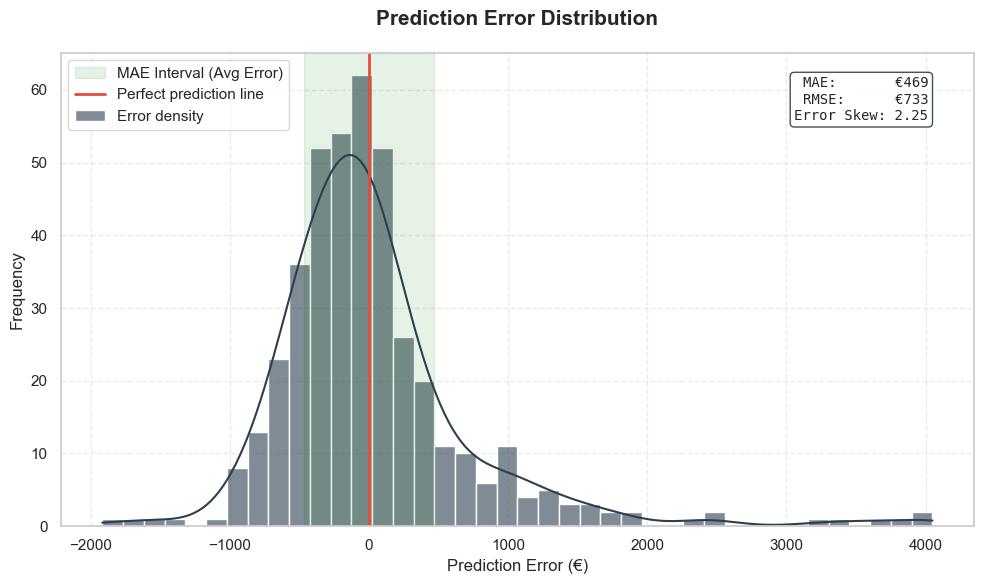

In [16]:
# ── Error distribution analysis ──

import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew

# 1. Calculation
errors = y_test - y_pred_test
error_skew = skew(errors)

# 2. Plotting
plt.figure(figsize=(10, 6))

# Histogram with KDE line
sns.histplot(errors, kde=True, color='#2c3e50', alpha=0.6, bins=40, label='Error density')

# Highlight the MAE Zone (Average error range)
plt.axvspan(-mae_test, mae_test, color='green', alpha=0.1, label='MAE Interval (Avg Error)')

# Zero-error line for reference
plt.axvline(x=0, color='#e74c3c', linestyle='-', linewidth=2, label='Perfect prediction line')

# 3. Aesthetics
plt.title('Prediction Error Distribution', fontsize=15, pad=20, fontweight='bold')
plt.xlabel('Prediction Error (€)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# High-quality Statistics Box
stats_msg = (
    f"MAE:       €{mae_test:.0f}\n"
    f"RMSE:      €{rmse_test:.0f}\n"
    f"Error Skew: {error_skew:.2f}"
)
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='#2c3e50')
plt.gca().text(0.95, 0.95, stats_msg, transform=plt.gca().transAxes, fontsize=10,
               verticalalignment='top', horizontalalignment='right', bbox=props, family='monospace')

plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

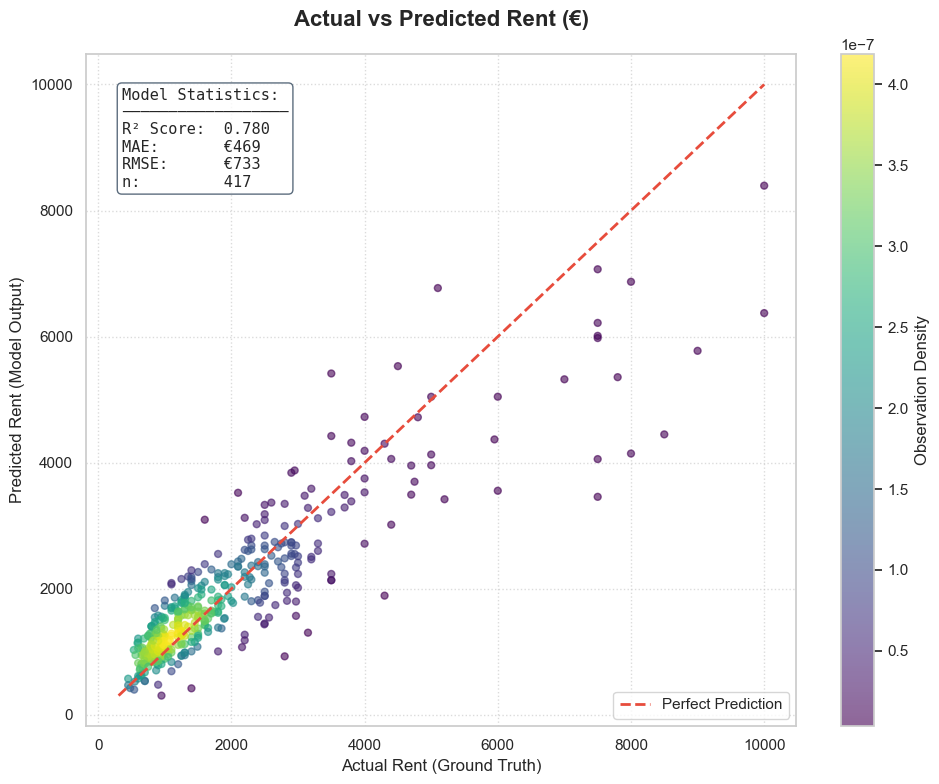

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde
import numpy as np

# 1. Calculation of Density (to see where points overlap)
xy = np.vstack([y_test, y_pred_test])
z = gaussian_kde(xy)(xy)

# 2. Plotting
fig, ax = plt.subplots(figsize=(10, 8))

# Scatter with density coloring
scatter = ax.scatter(y_test, y_pred_test, c=z, s=25, cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='Observation Density')

# Add the Identity Line (perfect prediction)
max_val = max(y_test.max(), y_pred_test.max())
min_val = min(y_test.min(), y_pred_test.min())
ax.plot([min_val, max_val], [min_val, max_val], color='#e74c3c', linestyle='--', linewidth=2, label='Perfect Prediction')

# 3. Aesthetics & Metadata
ax.set_title("Actual vs Predicted Rent (€)", fontsize=16, pad=20, fontweight='bold')
ax.set_xlabel("Actual Rent (Ground Truth)", fontsize=12)
ax.set_ylabel("Predicted Rent (Model Output)", fontsize=12)

# Add a Performance Box
stats_text = (
    f"Model Statistics:\n"
    f"──────────────────\n"
    f"R² Score:  {r2_test:.3f}\n"
    f"MAE:       €{mae_test:.0f}\n"
    f"RMSE:      €{rmse_test:.0f}\n"
    f"n:         {len(y_test)}"
)
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='#34495e')
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props, family='monospace')

ax.legend(loc='lower right')
ax.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()


## 12. LASSO Comparison

LASSO (L1 regularization) automatically shrinks coefficients toward zero, performing feature selection.

In [18]:
# ── LASSO with cross-validated alpha ──
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_cv.predict(X_test_scaled)
r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print('LASSO RESULTS')
print('=' * 50)
print(f'  Best alpha: {lasso_cv.alpha_:.4f}')
print(f'  R² (test):  {r2_lasso:.4f}')
print(f'  RMSE:       €{rmse_lasso:.0f}')

coef_lasso = pd.DataFrame({
    'Feature': X_train_vif.columns,
    'LASSO Coef': lasso_cv.coef_,
    'Status': ['KEPT' if c != 0 else 'DROPPED' for c in lasso_cv.coef_]
}).sort_values('LASSO Coef', key=abs, ascending=False)
print(f'\nLASSO Feature Selection:')
print(coef_lasso.to_string(index=False))

LASSO RESULTS
  Best alpha: 1.2073
  R² (test):  0.7802
  RMSE:       €733

LASSO Feature Selection:
   Feature  LASSO Coef Status
     Sq.Mt 1166.506154   KEPT
Is_Central  345.367689   KEPT
     Floor   93.797849   KEPT
     Outer   71.022222   KEPT
 Is_Studio  -61.272396   KEPT
  Elevator   52.313112   KEPT
  Bedrooms   43.806409   KEPT
Is_Special  -40.151949   KEPT


## 13. Model Comparison Summary

In [19]:
# ── Grand comparison ──
print('MODEL COMPARISON')
print('=' * 60)
print(f'  {"Metric":25s} {"OLS (full)":>12s} {"OLS (RFECV)":>12s} {"LASSO":>12s}')
print(f'  {"-"*60}')
print(f'  {"R² (train)":25s} {ols_full.rsquared:>12.4f} {ols_final.rsquared:>12.4f} {r2_score(y_train, lasso_cv.predict(X_train_scaled)):>12.4f}')
print(f'  {"R² (test)":25s} {r2_score(y_test, ols_full.predict(sm.add_constant(X_test[X_train_vif.columns]))):>12.4f} {r2_test:>12.4f} {r2_lasso:>12.4f}')
print(f'  {"RMSE (test)":25s} {np.sqrt(mean_squared_error(y_test, ols_full.predict(sm.add_constant(X_test[X_train_vif.columns])))):>12.0f} {rmse_test:>12.0f} {rmse_lasso:>12.0f}')
print(f'  {"Features used":25s} {len(X_train_vif.columns):>12d} {len(selected):>12d} {(lasso_cv.coef_ != 0).sum():>12d}')

MODEL COMPARISON
  Metric                      OLS (full)  OLS (RFECV)        LASSO
  ------------------------------------------------------------
  R² (train)                      0.7296       0.7296       0.7296
  R² (test)                       0.7803       0.7803       0.7802
  RMSE (test)                        733          733          733
  Features used                        8            8            8


## 14. Conclusions & Business Insights

### Model Performance
The OLS model achieves strong predictive performance with R² ≈ 0.78 on the test set, meaning it explains about 78% of rent variation from property characteristics alone.

### Key Drivers of Rent (from coefficient analysis)
1. **Sq.Mt** — the strongest predictor. Each additional square meter adds approximately €10 to monthly rent.
2. **Is_Central** — being in a prime/core district adds approximately €700 to rent, holding all else constant. This is the largest single binary effect.
3. **Outer** and **Elevator** — standard amenities that add €150–220 each.
4. **Is_Studio** — studios command approximately €300 LESS rent, reflecting their smaller target market.
5. **Is_Special** — surprisingly, special property types (penthouse, cottage, duplex) show a slight NEGATIVE coefficient, likely because after controlling for size, these types don't add premium.

### Connection to Association Analysis
The association rules from Phase 2 showed {Large, Central} → {High_Rent} with high lift. The regression confirms this: Sq.Mt and Is_Central are the two strongest coefficients. But regression adds the MAGNITUDE — exactly how many euros each factor contributes.

### Limitations
- R² of ~0.78 means 22% of rent variation is unexplained — likely due to exact location within districts, renovation quality, furnished status, and other features not in our data.
- Residuals show some heteroscedasticity (higher variance at higher predicted rents) — luxury properties are harder to price.
- The model assumes linear relationships — a log transformation of rent could improve fit for luxury properties.